In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

In [3]:
DATASET_PATH = r"C:\Users\pragy\Downloads\archive"

In [4]:
def load_dataset_metadata(root_path):
    data = []
    
    for material in ['D', 'P', 'W']:
        material_path = os.path.join(root_path, material)
        
        if not os.path.exists(material_path):
            print(f"Warning: Folder {material} not found in {root_path}")
            continue
            
        for folder_name in os.listdir(material_path):
            if folder_name.startswith('C'):
                condition = 'Cracked'
                label = 1
            elif folder_name.startswith('U'):
                condition = 'Uncracked'
                label = 0
            else:
                continue
                
            folder_full_path = os.path.join(material_path, folder_name)
            image_files = glob.glob(os.path.join(folder_full_path, "*.jpg"))
            
            for img_file in image_files:
                data.append({
                    'filepath': img_file,
                    'material': material,
                    'condition': condition,
                    'label': label         
                })
    
    return pd.DataFrame(data)

In [ ]:
print("Scanning dataset files... (this might take a moment)")
df = load_dataset_metadata(DATASET_PATH)

print(f"Total Images Found: {len(df)}")
print("-" * 30)
print(df.head())
print("-" * 30)

Scanning dataset files... (this might take a moment)
Total Images Found: 56092
------------------------------
                                            filepath material condition  label
0  C:\Users\pragy\Downloads\archive\D\CD\7001-115...        D   Cracked      1
1  C:\Users\pragy\Downloads\archive\D\CD\7001-139...        D   Cracked      1
2  C:\Users\pragy\Downloads\archive\D\CD\7001-151...        D   Cracked      1
3  C:\Users\pragy\Downloads\archive\D\CD\7001-157...        D   Cracked      1
4  C:\Users\pragy\Downloads\archive\D\CD\7001-169...        D   Cracked      1
------------------------------


C:\Users\pragy\AppData\Local\Temp\ipykernel_24448\1449312600.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='material', data=df, palette='viridis', order=['D', 'P', 'W'])


Text(0, 0.5, 'Count')

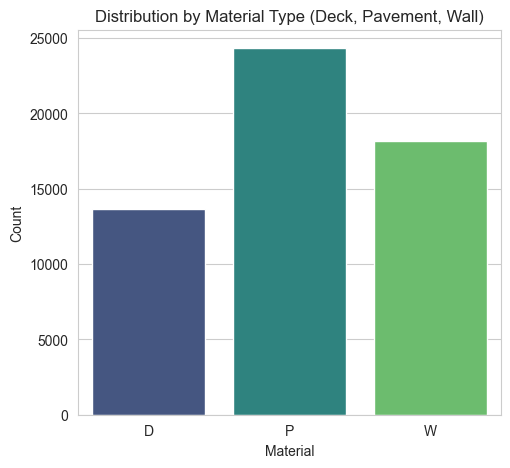

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='material', data=df, palette='viridis', order=['D', 'P', 'W'])
plt.title("Distribution by Material Type (Deck, Pavement, Wall)")
plt.xlabel("Material")
plt.ylabel("Count")


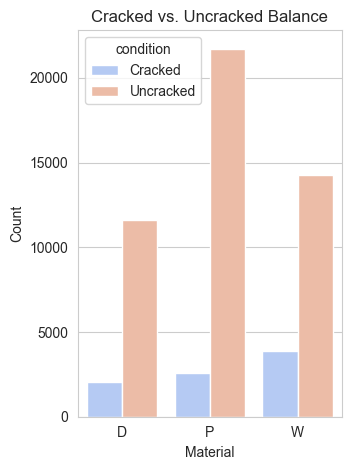

In [7]:
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 100))

plt.subplot(1, 2, 2)
sns.countplot(x='material', hue='condition', data=df, palette='coolwarm', order=['D', 'P', 'W'])
plt.title("Cracked vs. Uncracked Balance")
plt.xlabel("Material")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [8]:
def plot_samples(df, n_samples=3):
    
    materials = ['D', 'P', 'W']
    fig, axes = plt.subplots(len(materials), 2, figsize=(10, 12))
    
    for i, material in enumerate(materials):
        cracked_sample = df[(df['material'] == material) & (df['condition'] == 'Cracked')].sample(1).iloc[0]
        img_c = Image.open(cracked_sample['filepath'])
        
        uncracked_sample = df[(df['material'] == material) & (df['condition'] == 'Uncracked')].sample(1).iloc[0]
        img_u = Image.open(uncracked_sample['filepath'])
        
        axes[i, 0].imshow(img_c)
        axes[i, 0].set_title(f"{material} - Cracked")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img_u)
        axes[i, 1].set_title(f"{material} - Uncracked")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()


Visualizing random samples...


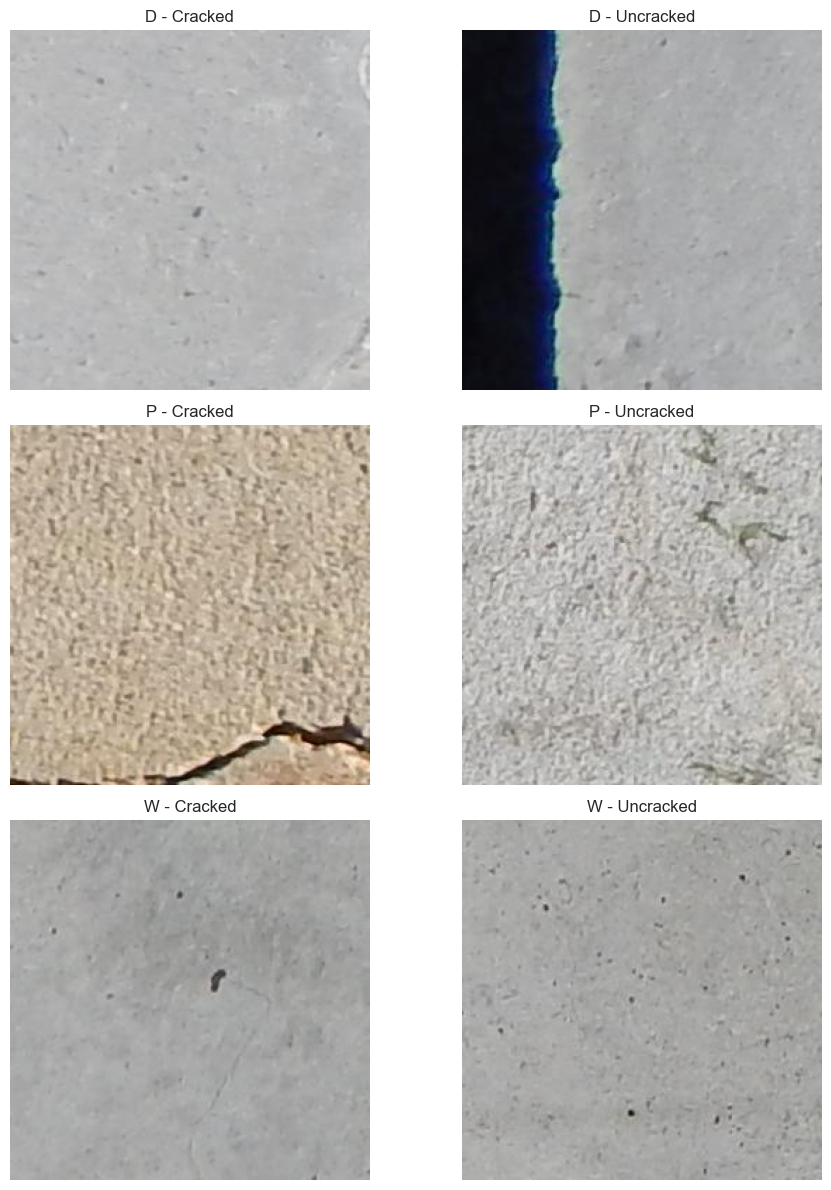

In [9]:
print("\nVisualizing random samples...")
plot_samples(df)


Calculating pixel intensities (sampling 1000 images for speed)...


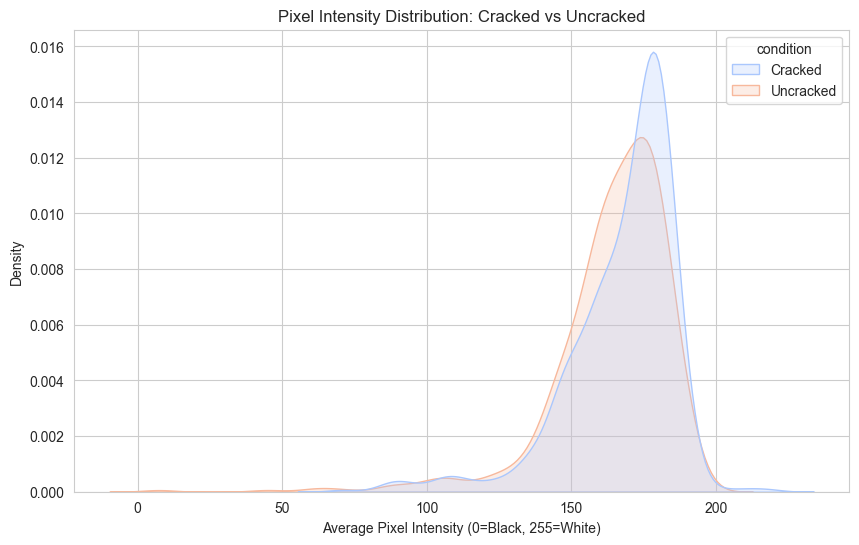

In [11]:
print("\nCalculating pixel intensities (sampling 1000 images for speed)...")
subset_df = df.groupby(['condition', 'material']).sample(n=200, random_state=42)

def get_avg_brightness(filepath):
    with Image.open(filepath) as img:
        return np.mean(np.array(img.convert('L')))

subset_df['brightness'] = subset_df['filepath'].apply(get_avg_brightness)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=subset_df, x='brightness', hue='condition', fill=True, palette='coolwarm')
plt.title("Pixel Intensity Distribution: Cracked vs Uncracked")
plt.xlabel("Average Pixel Intensity (0=Black, 255=White)")
plt.show()

In [19]:
!pip install scikit-image

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.9 MB 1.4 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/11.9 MB 1.9 MB/s eta 0:00:06
   --------- ------------------------------ 2.9/11.9 MB 3.2 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/11.9 MB 4.8 MB/s eta 0:00:02
   ------------------------------- -------- 9.4/11.9 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------  11.8/11.9 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 7.4 MB/s  0:00:02

   -----------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Calculating Frangi Vesselness (The 'Crack-Likeness' Metric)...


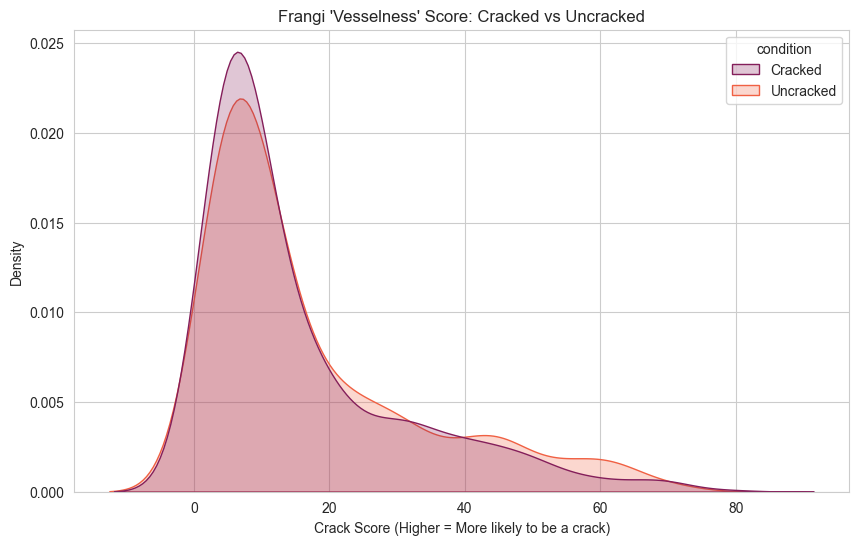

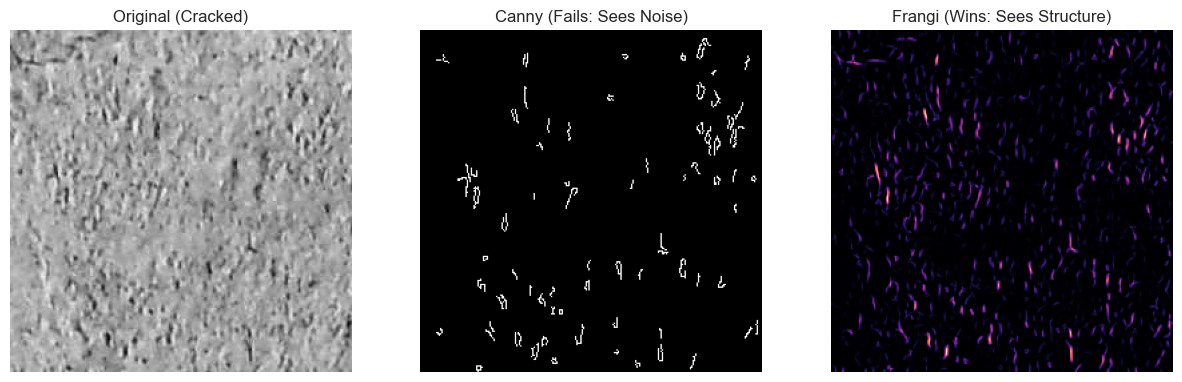

In [20]:
from skimage.filters import frangi, hessian
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


print("Calculating Frangi Vesselness (The 'Crack-Likeness' Metric)...")

def get_frangi_score(filepath):
    img = cv2.imread(filepath, 0)
    
    filtered_image = frangi(img, sigmas=range(1, 5), black_ridges=True)
    
    return np.mean(filtered_image) * 1000

subset_df['crack_score'] = subset_df['filepath'].apply(get_frangi_score)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=subset_df, x='crack_score', hue='condition', fill=True, palette='rocket')

plt.title("Frangi 'Vesselness' Score: Cracked vs Uncracked")
plt.xlabel("Crack Score (Higher = More likely to be a crack)")
plt.show()

row = subset_df[subset_df['condition'] == 'Cracked'].iloc[0]
img_path = row['filepath']

original = cv2.imread(img_path, 0)
canny = cv2.Canny(original, 100, 200)
frangi_out = frangi(original, sigmas=range(1, 5), black_ridges=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(original, cmap='gray')
ax[0].set_title("Original (Cracked)")
ax[0].axis('off')

ax[1].imshow(canny, cmap='gray')
ax[1].set_title("Canny (Fails: Sees Noise)")
ax[1].axis('off')

ax[2].imshow(frangi_out, cmap='magma')
ax[2].set_title("Frangi (Wins: Sees Structure)")
ax[2].axis('off')
plt.show()